In [2]:
import numpy as np
import pandas as pd
import os.path as osp
import os
import matplotlib.pyplot as plt

---

In [79]:
path = "results/lj_muVT_pore_H_2.8_20250910_142339"

df = pd.read_csv(osp.join(path, "stats_lj_pore.csv"), sep=" ", comment="#")

df.head()

,step,temp,pe,disjoin_pressure,vol,natoms
0,0,1.200000,512988.0,3653.47,137.2,98
1,10,1.117750,272726.0,3300.87,137.2,92
2,20,1.023320,151448.0,2924.56,137.2,84
3,30,0.870405,45367.1,2158.56,137.2,71
4,40,0.806353,35841.7,1744.02,137.2,66


In [80]:
len(df["step"])

10001

In [81]:
begin = 0

In [82]:
np.std(np.sort(df["pe"][begin:])[:int(len(df["pe"][begin:]) * 0.9)])

np.float64(24.41977159035776)

In [83]:
def quintile(arr, q):
    q_array = np.sort(arr)[:int(len(arr) * 0.9)]
    return np.mean(q_array), np.std(q_array)

In [84]:
np.abs(df["pe"].to_numpy() - mean) < std

array([False, False, False, ...,  True,  True,  True], shape=(10001,))

-561.1954594444444 24.41977159035776


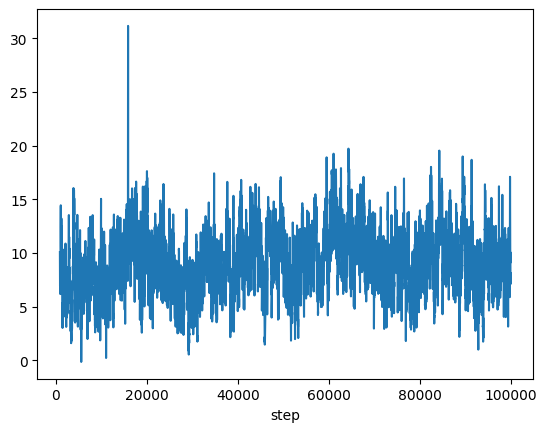

In [88]:
mean, std = quintile(df["pe"].to_numpy()[begin:], 0.98)
print(mean, std)
index = np.argwhere(np.abs(df["pe"].to_numpy()[begin:] - mean) < 5 * std)

plt.plot(df["step"].to_numpy()[index], df["disjoin_pressure"].to_numpy()[index])
# plt.ylim(bottom=-1000, top=100)
plt.xlabel("step")
plt.show()




In [89]:
rhos = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

press_means = []
press_stds = []
begin = 18000
for rho in rhos:
    pattern = f"lj_nvt_T_0.9_rho_{rho}_"
    for folder in os.listdir("results"):
        if folder.startswith(pattern):
            path = osp.join("results", folder)
            break

    df = pd.read_csv(osp.join(path, "stats_lj_nvt.csv"), sep=" ", comment="#")
    press_means.append(df["press"][begin:].mean())
    press_stds.append(df["press"][begin:].std())

/tmp/ipykernel_94518/1617936583.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


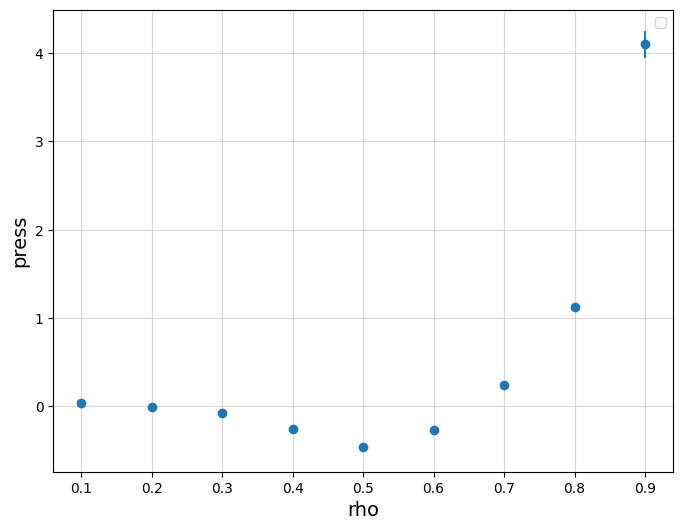

In [40]:
plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)

plt.errorbar(rhos, press_means, yerr=press_stds, fmt="o")

plt.xlabel("rho", fontsize=14)
plt.ylabel("press", fontsize=14)
plt.legend()
plt.show()

---

152.1886650166667 454.3956109974544
-398.9338568888889 18.81634181405347
-428.7645504444444 16.84557710523282
-1871.03644 36.904629747405224
-1765.1273788888889 35.45833896790867
-1648.9185744444446 52.177833475539444
-1567.9779688888889 26.646609443419685
-1550.08097 34.55519669075663
-1753.974581111111 53.3605884019499
-2190.8865288888887 118.34944887406883
-2562.973501111111 180.6960939853248
-2676.6815744444443 131.82446399823183
-2683.177958888889 135.2463564709497
-2665.6505166666666 86.84053216218123
-2552.661981111111 88.86607322168493
-2513.734334444445 105.76851399627044
-2548.255363333333 74.46645639004323
-2578.7766555555554 83.28110668968765
-2753.42819 98.55972915728428


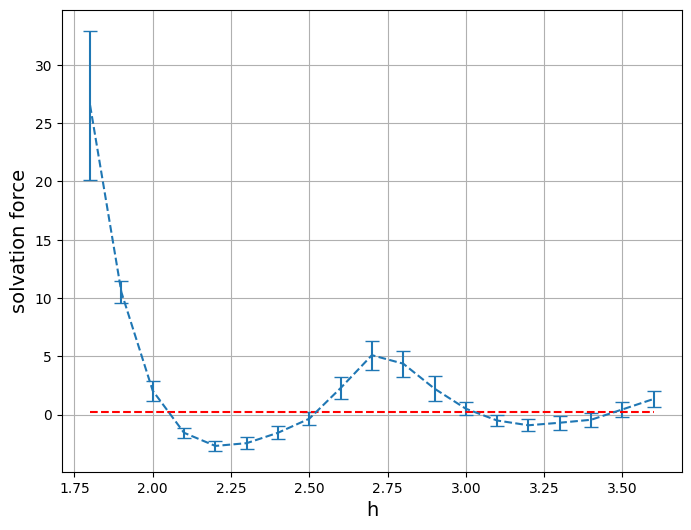

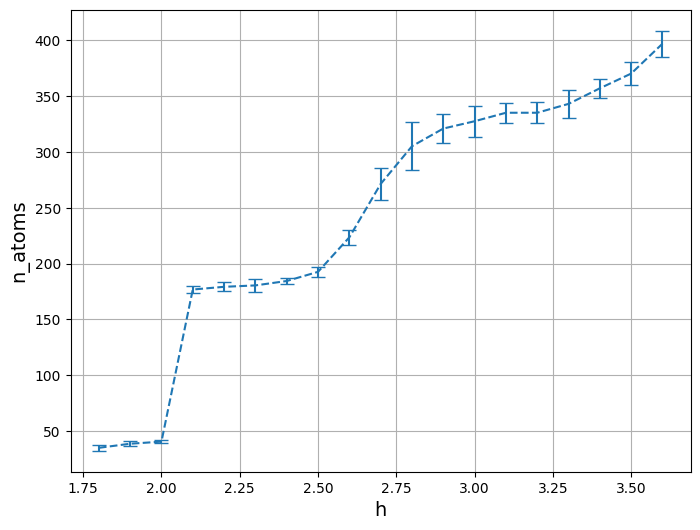

In [93]:
# H = [str(i.round(1)) for i in np.arange(1.8, 4.1, 0.2)]
H = [str(i.round(1)) for i in np.arange(1.8, 3.65, 0.1)]

mean_solvation_force_list = []
std_solvation_force_list = []

mean_n_atoms_list = []
std_n_atoms_list = []

begin = 0
order = -1

for h in H:
    candidates = []
    for folder in os.listdir('results'):
        if folder.startswith('lj_muVT_pore_H_'+h):
            candidates.append(folder)

    candidates.sort(key=lambda x: int(x.split('_')[-1]))
    assert len(candidates) > 0, f"No results found for h={h}"

    df = pd.read_csv(osp.join('results', candidates[order], "stats_lj_pore.csv"), sep=" ", comment="#")

    mean, std = quintile(df["pe"][begin:].to_numpy(), 0.99)
    print(mean, std)
    index = np.argwhere(np.abs(df["pe"][begin:].to_numpy() - mean) < 5 * std)

    mean_solvation_force_list.append(np.mean(df["disjoin_pressure"][begin:].to_numpy()[index]/2))
    std_solvation_force_list.append(np.std(df["disjoin_pressure"][begin:].to_numpy()[index]/2))
    mean_n_atoms_list.append(np.mean(df["natoms"][begin:].to_numpy()[index]))
    std_n_atoms_list.append(np.std(df["natoms"][begin:].to_numpy()[index]))

plt.figure(figsize=(8, 6))
plt.grid(True)

start_point = 0
plt.errorbar(np.array(list(map(float, H)))[start_point:], mean_solvation_force_list[start_point:], yerr=std_solvation_force_list[start_point:], fmt='--', capsize=5)
plt.hlines(0.2, float(H[0]), float(H[-1]), colors='red', linestyles='--')
# plt.errorbar(list(map(float, H)), mean_n_atoms_list, yerr=std_n_atoms_list, fmt='o', capsize=5)
# plt.scatter(df["step"][begin:], df["pressure_total"][begin:], s=4)
plt.xlabel('h', fontsize=14)
plt.ylabel('solvation force', fontsize=14)
# plt.ylim(-5, 6)
# plt.title(f'T={T}', fontsize=16)
plt.show()


plt.figure(figsize=(8, 6))
plt.grid(True)

plt.errorbar(np.array(list(map(float, H))), mean_n_atoms_list, yerr=std_n_atoms_list, fmt='--', capsize=5)
plt.xlabel('h', fontsize=14)
plt.ylabel('n_atoms', fontsize=14)
# plt.title(f'T={T}', fontsize=16)
plt.show()